<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/23521013_Arief_Purnama_Muharram_IF5171_DTLEM_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project #1: Census Income Prediction
___


## Step 1: Required Packages

In [ ]:
!pip install numpy
!pip install pandas
!pip install scikit-learn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


## Step 2: Import Dataset

In [ ]:
import pandas as pd


# Load dataset CSV
train_dataset = pd.read_csv('census_train.csv')
test_dataset = pd.read_csv('census_test.csv')

# Print train dataset info
train_dataset.info()

print('\n')

# Print test dataset info
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (t

## Step 3: Dataset Exploration

### 3.1: Visualization Helper

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [ ]:
def create_countplot(data, xlabel=None, ylabel=None, title=None, horizontal=False, figsize=(7,7)):
  data = data.value_counts()
  plt.style.use('seaborn')
  plt.figure(figsize=figsize)
  if horizontal:
    sns.barplot(data.values, data.index, palette='colorblind') 
  else:
    sns.barplot(data.index, data.values, palette='colorblind')
  plt.title(title, fontdict={
      'fontsize': 20, 'fontweight': 'bold'
  })
  plt.xlabel(xlabel, fontdict={
      'fontsize': 15
  })
  plt.ylabel(ylabel, fontdict={
      'fontsize': 15
  })
  plt.tick_params(labelsize=12)
  plt.show()

In [ ]:
def create_countplot_with_hue(data, hue, xlabel=None, ylabel=None, title=None, figsize=(7,7)):
  plt.style.use('seaborn')
  plt.figure(figsize=figsize)
  sns.countplot(data, hue=hue, palette='colorblind')
  plt.title(title, fontdict={
      'fontsize': 20, 'fontweight': 'bold'
  })
  plt.xlabel(xlabel, fontdict={
      'fontsize': 15
  })
  plt.ylabel(ylabel, fontdict={
      'fontsize': 15
  })
  plt.tick_params(labelsize=12)
  plt.show()

In [ ]:
def create_distplot(data, xlabel=None, ylabel=None, title=None, bins=10, figsize=(7,7)):
  plt.style.use('seaborn')
  plt.figure(figsize=figsize)
  sns.distplot(data, bins=bins)
  plt.title(title, fontdict={
      'fontsize': 20, 'fontweight': 'bold'
  })
  plt.xlabel(xlabel, fontdict={
      'fontsize': 15
  })
  plt.ylabel(ylabel, fontdict={
      'fontsize': 15
  })
  plt.tick_params(labelsize=12)
  plt.show()

### 3.2: Distribution Analysis

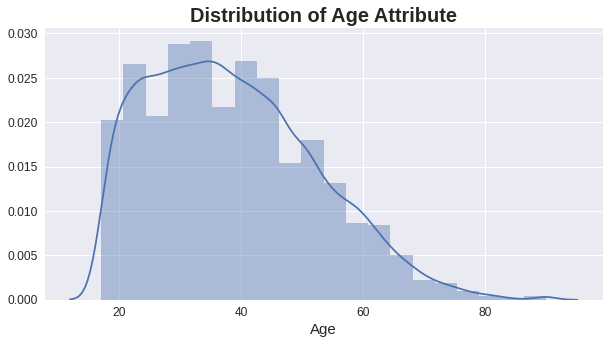

In [ ]:
create_distplot(train_dataset['age'], xlabel='Age', title='Distribution of Age Attribute', bins=20, figsize=(10,5))

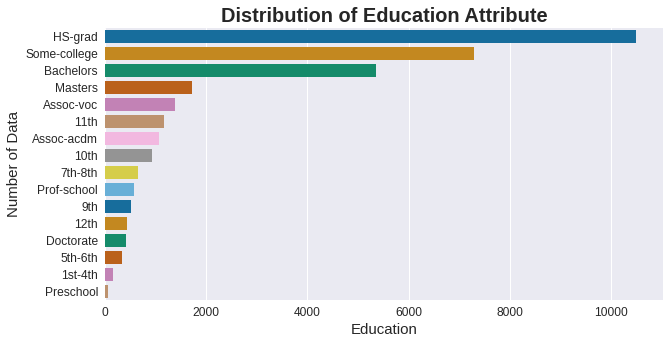

In [ ]:
create_countplot(
    train_dataset['education'], 
    xlabel='Education', ylabel='Number of Data', 
    title='Distribution of Education Attribute', 
    figsize=(10,5), horizontal=True)

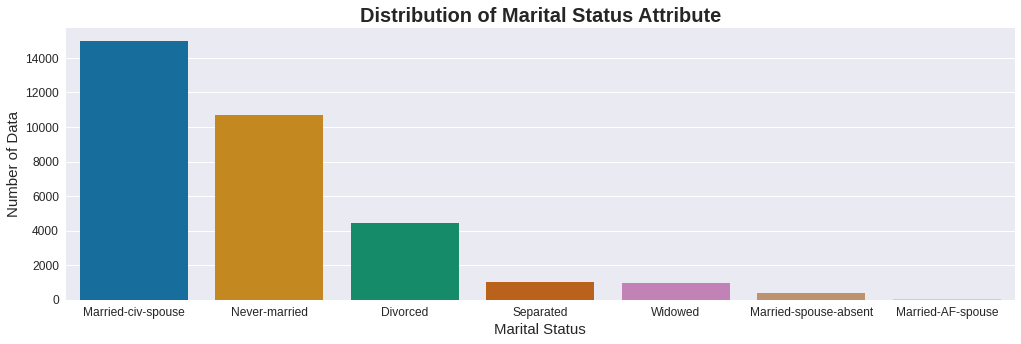

In [ ]:
create_countplot(
    train_dataset['marital-status'],
    xlabel='Marital Status', ylabel='Number of Data',
    title='Distribution of Marital Status Attribute',
    figsize=(17,5)
)

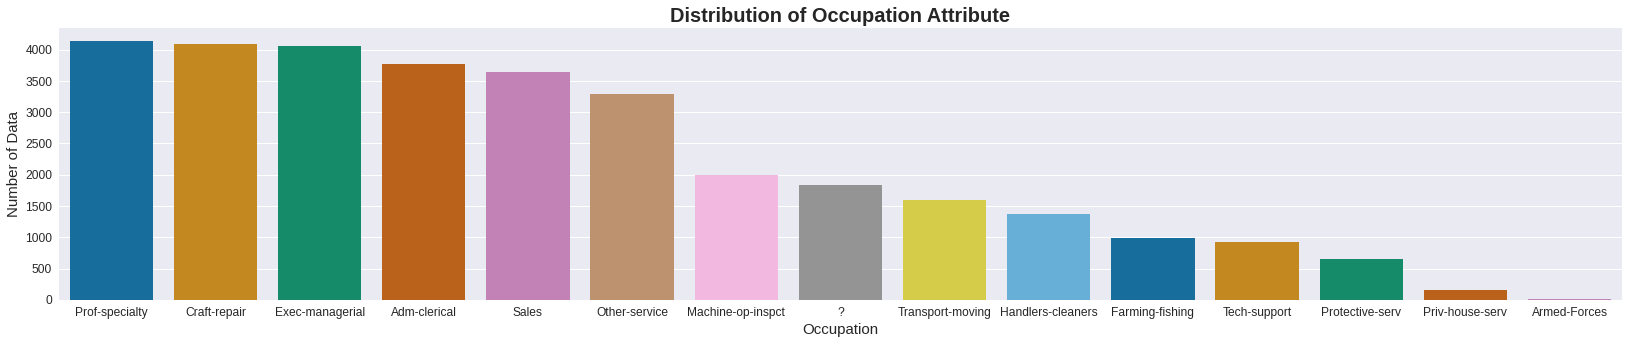

In [ ]:
create_countplot(
    train_dataset['occupation'],
    xlabel='Occupation', ylabel='Number of Data',
    title='Distribution of Occupation Attribute',
    figsize=(28,5)
)

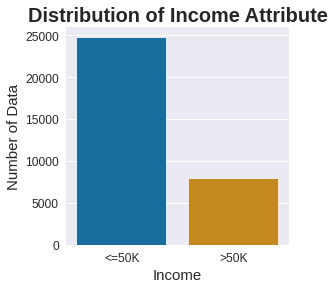

In [ ]:
create_countplot(
    train_dataset['income'],
    xlabel='Income', ylabel='Number of Data',
    title='Distribution of Income Attribute',
    figsize=(4,4)
)

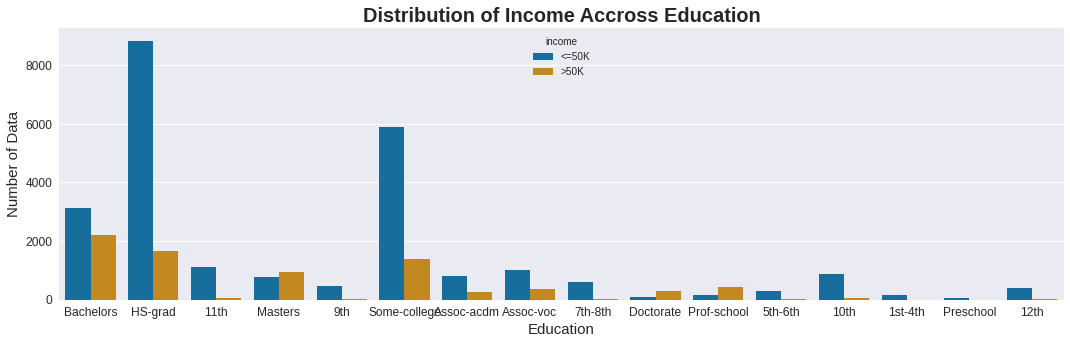

In [ ]:
create_countplot_with_hue(
    train_dataset['education'], hue=train_dataset['income'],
    xlabel='Education', ylabel='Number of Data',
    title='Distribution of Income Accross Education',
    figsize=(18,5)
)

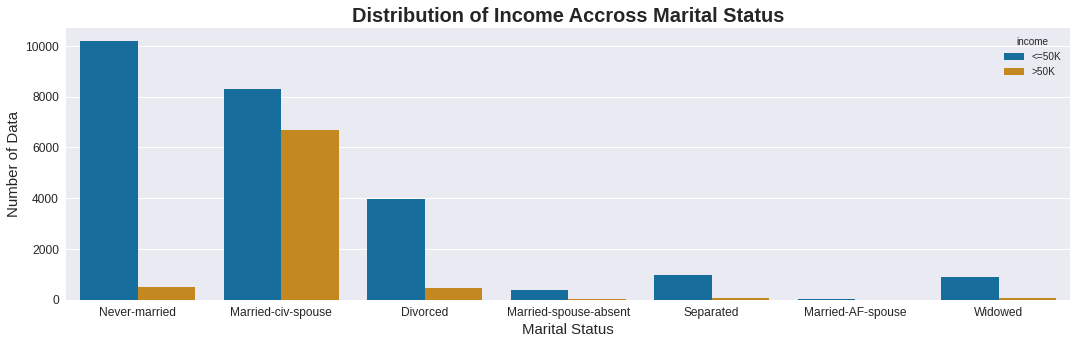

In [ ]:
create_countplot_with_hue(
    train_dataset['marital-status'], hue=train_dataset['income'],
    xlabel='Marital Status', ylabel='Number of Data',
    title='Distribution of Income Accross Marital Status',
    figsize=(18,5)
)

## Step 4: Dataset Cleaning

### 4.1: Fix '?' Value

In [ ]:
import numpy as np


train_dataset = train_dataset.replace('?', np.nan)
test_dataset = test_dataset.replace('?', np.nan)

In [ ]:
round((train_dataset.isnull().sum() / train_dataset.shape[0]) * 100, 2).astype(str) + ' %'

age                0.0 %
workclass         5.64 %
fnlwgt             0.0 %
education          0.0 %
education-num      0.0 %
marital-status     0.0 %
occupation        5.66 %
relationship       0.0 %
race               0.0 %
sex                0.0 %
capital-gain       0.0 %
capital-loss       0.0 %
hours-per-week     0.0 %
native-country    1.79 %
income             0.0 %
dtype: object

In [ ]:
round((test_dataset.isnull().sum() / test_dataset.shape[0]) * 100, 2).astype(str) + ' %'

age                0.0 %
workclass         5.91 %
fnlwgt             0.0 %
education          0.0 %
education-num      0.0 %
marital-status     0.0 %
occupation        5.93 %
relationship       0.0 %
race               0.0 %
sex                0.0 %
capital-gain       0.0 %
capital-loss       0.0 %
hours-per-week     0.0 %
native-country    1.68 %
income             0.0 %
dtype: object

In [ ]:
columns_with_nan = ['workclass', 'occupation', 'native-country']

In [ ]:
for col in columns_with_nan:
  train_dataset[col].fillna(train_dataset[col].mode()[0], inplace=True)

for col in columns_with_nan:
  test_dataset[col].fillna(test_dataset[col].mode()[0], inplace=True)

### 4.2: Nullability Checking

#### Check on Train Dataset

In [ ]:
# Check for train dataset nullability

train_dataset.isnull().any().any()

False

#### Check on Test Dataset

In [ ]:
# Check for test dataset nullability

test_dataset.isnull().any().any()

False

### 4.3: Duplicate Checking

#### Check on Train Dataset

In [ ]:
# Check for duplicate items on train dataset

train_dataset.duplicated().any()

True

In [ ]:
# Count duplicate items on train dataset 

len(train_dataset[train_dataset.duplicated()])

24

In [ ]:
# Show duplicate items on train dataset

train_dataset[train_dataset.duplicated()]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
15059,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
17040,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
18555,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [ ]:
# Remove duplicate items on train dataset

train_dataset.drop_duplicates(keep='first', inplace=True)

#### Check on Test Dataset

In [ ]:
# Check for duplicate items on test dataset

test_dataset.duplicated().any()

True

In [ ]:
# Count duplicate items on test dataset 

len(test_dataset[test_dataset.duplicated()])

5

In [ ]:
# Show duplicate items on test dataset 

test_dataset[test_dataset.duplicated()]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
864,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
11189,37,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K
11212,29,Private,36440,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
13848,30,Private,180317,Assoc-voc,11,Divorced,Machine-op-inspct,Not-in-family,White,Male,0,0,40,United-States,<=50K
15960,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K


In [ ]:
# Remove duplicate items on test dataset 

test_dataset.drop_duplicates(keep='first', inplace=True)

### 4.4: Print Dataset Sample

In [ ]:
# Print train dataset
train_dataset.head(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [ ]:
# Print test dataset
test_dataset.head(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


## Step 5: Dataset Transformation

### 5.1: Transformation Helper

In [ ]:
def transform_attribute_values(dataset, attribute_name, attribute_dictionary = None): 
  '''
  Args:
    dataset               : Dataset DataFrame object
    attribute_name        : Attribute name to tansform
    attribute_dictionary  : Attribute dictionary as reference (optional)
  
  Return:
    transformed_attribute : Transformed dataset attribute DataFrame object
    dict_attribute        : Attribute dictionary used to transform the attributes
  '''

  if attribute_dictionary is None:
    attributes = list(dataset[attribute_name].unique())
    dict_attribute = {}
    for i in range(len(attributes)):
      if attributes[i] not in dict_attribute:
        dict_attribute[attributes[i]] = i + 1
  else:
    dict_attribute = attribute_dictionary
  
  transformed_attribute = dataset[attribute_name].apply(lambda x: dict_attribute[x])

  return (transformed_attribute, dict_attribute)

In [ ]:
def transform_helper(dataset, attributes, dictionary = None):
  '''
  Args:
    dataset     : Dataset DataFrame object
    attributes  : List of attributes name to transform
    dictionary  : Attribute dictionary with attribute name as its key (optional)
  
  Return:
    dataset     : Dataset DataFrame object
    used_dict   : Attribute dictionary used to transform the attributes
  '''

  used_dict = {}

  if dictionary is not None:
    used_dict = dictionary

  for attribute in attributes:
    if (used_dict.get(attribute) == None):
      dataset[attribute], used_dict[attribute] = transform_attribute_values(dataset, attribute)
    else:
      dataset[attribute], _ = transform_attribute_values(dataset, attribute, used_dict[attribute])
  
  return (dataset, used_dict)

In [ ]:
def check_untransformed_values(dataset, attributes, dictionary):
  '''
  Args:
    dataset     : Dataset DataFrame object
    attributes  : List of attributes name to check
    dictionary  : Attribute dictionary with attribute name as its key

  Return:
    True  : If any untransformed values exists
    False : If all values have been transformed
  '''

  result = False

  for attribute in attributes:
    check = dataset[attribute].isin(list(dictionary[attribute])).any()
    if check == True:
      result == check
  
  return result

### 5.2: Select Attributes to Transform

In [ ]:
# Get attributes name
attributes_need_to_transform = list(train_dataset.select_dtypes(exclude=['int', 'float']).columns)

# Print attributes name
print('Attributes need to transform:', attributes_need_to_transform)

Attributes need to transform: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


### 5.3: Transform Attributes

In [ ]:
# Transform attributes of train dataset
_, attributes_dict = transform_helper(train_dataset, attributes_need_to_transform)

# Transform attributes of test dataset
_, _ = transform_helper(test_dataset, attributes_need_to_transform, attributes_dict)

### 5.4: Check Transformed Attributes Quality

In [ ]:
# Define which attributes to check
attributes_to_check = attributes_need_to_transform

# Check for untransformed attributes
print('Untransformed attributes in train dataset:', 
      check_untransformed_values(train_dataset, attributes_to_check, attributes_dict))
print('Untransformed attributes in test dataset:', 
      check_untransformed_values(test_dataset, attributes_to_check, attributes_dict))

Untransformed attributes in train dataset: False
Untransformed attributes in test dataset: False


### 5.5: Dataset Checkup

In [ ]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  int64
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  int64
 4   education-num   32537 non-null  int64
 5   marital-status  32537 non-null  int64
 6   occupation      32537 non-null  int64
 7   relationship    32537 non-null  int64
 8   race            32537 non-null  int64
 9   sex             32537 non-null  int64
 10  capital-gain    32537 non-null  int64
 11  capital-loss    32537 non-null  int64
 12  hours-per-week  32537 non-null  int64
 13  native-country  32537 non-null  int64
 14  income          32537 non-null  int64
dtypes: int64(15)
memory usage: 4.0 MB


In [ ]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16276 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             16276 non-null  int64
 1   workclass       16276 non-null  int64
 2   fnlwgt          16276 non-null  int64
 3   education       16276 non-null  int64
 4   education-num   16276 non-null  int64
 5   marital-status  16276 non-null  int64
 6   occupation      16276 non-null  int64
 7   relationship    16276 non-null  int64
 8   race            16276 non-null  int64
 9   sex             16276 non-null  int64
 10  capital-gain    16276 non-null  int64
 11  capital-loss    16276 non-null  int64
 12  hours-per-week  16276 non-null  int64
 13  native-country  16276 non-null  int64
 14  income          16276 non-null  int64
dtypes: int64(15)
memory usage: 2.0 MB


In [ ]:
train_dataset.head(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,1,77516,1,13,1,1,1,1,1,2174,0,40,1,1
1,50,2,83311,1,13,2,2,2,1,1,0,0,13,1,1
2,38,3,215646,2,9,3,3,1,1,1,0,0,40,1,1


In [ ]:
test_dataset.head(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,3,7,1,10,4,2,1,0,0,40,1,1
1,38,3,89814,2,9,2,9,2,1,1,0,0,50,1,1
2,28,5,336951,7,12,2,12,2,1,1,0,0,40,1,2


## Step 6: Model Development

### 6.1: Create Train, Test, and Validation Dataset

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    train_dataset.drop(columns=['income']), train_dataset['income'], test_size=0.3, random_state=0
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Y_train shape:', y_train.shape)
print('Y_test shape:', y_test.shape)

X_train shape: (22775, 14)
X_test shape: (9762, 14)
Y_train shape: (22775,)
Y_test shape: (9762,)


### 6.2: Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier


dec_tree_model = DecisionTreeClassifier(random_state=0)

In [ ]:
dec_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
y_pred_dec_tree_model = dec_tree_model.predict(X_test)

### 6.3: Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier


rand_forest_model = RandomForestClassifier(random_state=0)

In [ ]:
rand_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
y_pred_rand_forest_model = rand_forest_model.predict(X_test)

### 6.4: XGB Classifier

In [ ]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier()

In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier()

In [ ]:
y_pred_xgb_model = xgb_model.predict(X_test)

## Step 7: Model Evaluation

### 7.1: Eval Helper

In [ ]:
from sklearn import metrics


def eval_model(eval_name, y_test, y_pred):
  '''
  Args:
    eval_name : Model test name
    y_test    : Ground truth values
    y_pred    : Prediction values

  Return:
    eval_name       : Model test name
    result_accuracy_score  : Model accuracy score
    result_f1_score        : F1 accuracy score
  '''

  result_accuracy_score = metrics.accuracy_score(y_test, y_pred)
  result_f1_score = metrics.f1_score(y_test, y_pred)

  return eval_name, result_accuracy_score, result_f1_score

### 7.2: Eval on Test Dataset

In [ ]:
import pandas as pd


eval_results = pd.DataFrame(columns=['Eval Name', 'Accuracy Score', 'F1 Score'])

# Decision tree evaluation
eval_name, accuracy_score, f1_score = eval_model('Decision Tree', y_test, y_pred_dec_tree_model)
eval_results = eval_results.append(pd.DataFrame([[eval_name, accuracy_score, f1_score]], columns=['Eval Name', 'Accuracy Score', 'F1 Score']), ignore_index=True)

# Random forest evaluation
eval_name, accuracy_score, f1_score = eval_model('Random Forest', y_test, y_pred_rand_forest_model)
eval_results = eval_results.append(pd.DataFrame([[eval_name, accuracy_score, f1_score]], columns=['Eval Name', 'Accuracy Score', 'F1 Score']), ignore_index=True)


# XGBoost evaluation
eval_name, accuracy_score, f1_score = eval_model('XGBoost', y_test, y_pred_xgb_model)
eval_results = eval_results.append(pd.DataFrame([[eval_name, accuracy_score, f1_score]], columns=['Eval Name', 'Accuracy Score', 'F1 Score']), ignore_index=True)

eval_results

,Eval Name,Accuracy Score,F1 Score
0,Decision Tree,0.812743,0.874829
1,Random Forest,0.858636,0.908549
2,XGBoost,0.864577,0.913696


## Step 8: Save model

### 8.1: Dump Helper

In [ ]:
from joblib import dump, load


def save_model(model, name='model.joblib'):
  dump(model, name)

### 8.2: Dump Model

In [ ]:
selected_model = xgb_model
model_name = '23521013-Arief Purnama Muharram-IF5171-DTLEM-1.joblib'

save_model(selected_model, model_name)

## Step 9: Predict on 'Test' Production Dataset

### 9.1: Load Model

In [ ]:
loaded_model = load(model_name)

### 9.2: Load Dataset

In [ ]:
X_test_production = test_dataset.drop(columns=['income'])
y_test_production = test_dataset['income']

print('X_val shape:', X_test_production.shape)
print('Y_val shape:', y_test_production.shape)

X_val shape: (16276, 14)
Y_val shape: (16276,)


### 9.3: Predict Validation Set

In [ ]:
y_test_production_pred = loaded_model.predict(X_test_production)

### 9.4: Print Performance Result

In [ ]:
eval_name, accuracy_score, f1_score = eval_model('census_train.csv', y_test_production, y_test_production_pred)

print('[Performance Result]')
print('Eval name:', eval_name)
print('Accuracy score:', accuracy_score)
print('F1 score:', f1_score)

[Performance Result]
Eval name: census_train.csv
Accuracy score: 0.8631113295650037
F1 score: 0.9141028606677462


### 9.5: Save The Results

In [ ]:
import pandas as pd 


csv_name = '23521013-Arief Purnama Muharram-IF5171-DTLEM-1.csv'

ref_attribute_dict = {y: x for x, y in attributes_dict['income'].items()}

y_test_production_pred = pd.Series(y_test_production_pred)
y_test_production_pred = y_test_production_pred.apply(lambda x: ref_attribute_dict[x])

results = pd.DataFrame({'Id': range(len(y_test_production)), 'Prediction': y_test_production_pred})

results.to_csv(csv_name)

## Step 10: Conclusion

*   Terdapat 3 model yang dicoba dalam penyelesaian kasus 'census-income' ini, yaitu Decision Tree, Random Forest, dan XGBoost.
*   Model Decision Tree, Random Forest, dan XGBoost memberikan kinerja akurasi masing-masing 0.813, 0.858, dan 0,864.
*   Model XGBoost memberikan kinerja paling baik dengan akurasi mencapai 0.864 (86.4%).
*   Model XGBoost dipilih untuk diuji coba pada 'test' data dan memberikan hasil kinerja akurasi 0.863 dan F1 0.914.

